In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd, numpy as np, sqlite3, os

# Paths to your CSVs in Google Drive (change names if needed)
CSV = {
    "providers":   "/content/drive/MyDrive/providers_data.csv",
    "receivers":   "/content/drive/MyDrive/receivers_data.csv",
    "food_listings": "/content/drive/MyDrive/food_listings_data.csv",
    "claims":      "/content/drive/MyDrive/claims_data.csv",
}

DB_PATH = "/content/drive/MyDrive/food_waste.db"

# Helper to clean column names
def clean_cols(df):
    df = df.copy()
    df.columns = [c.strip().replace(" ","_") for c in df.columns]
    return df

def to_ymd(x):
    if pd.isna(x): return None
    dt = pd.to_datetime(x, errors="coerce", infer_datetime_format=True)
    return None if pd.isna(dt) else dt.strftime("%Y-%m-%d")

def to_iso(x):
    if pd.isna(x): return None
    dt = pd.to_datetime(x, errors="coerce", infer_datetime_format=True)
    return None if pd.isna(dt) else dt.strftime("%Y-%m-%d %H:%M:%S")

# Read CSVs
providers = clean_cols(pd.read_csv(CSV["providers"]))
receivers = clean_cols(pd.read_csv(CSV["receivers"]))
food = clean_cols(pd.read_csv(CSV["food_listings"]))
claims = clean_cols(pd.read_csv(CSV["claims"]))

# Recreate DB
if os.path.exists(DB_PATH): os.remove(DB_PATH)
conn = sqlite3.connect(DB_PATH)
conn.executescript("""
PRAGMA foreign_keys = ON;

CREATE TABLE providers(
    Provider_ID INTEGER PRIMARY KEY,
    Name TEXT, Type TEXT, Address TEXT, City TEXT, Contact TEXT
);

CREATE TABLE receivers(
    Receiver_ID INTEGER PRIMARY KEY,
    Name TEXT, Type TEXT, City TEXT, Contact TEXT
);

CREATE TABLE food_listings(
    Food_ID INTEGER PRIMARY KEY,
    Food_Name TEXT,
    Quantity INTEGER,
    Expiry_Date DATE,
    Provider_ID INTEGER,
    Provider_Type TEXT,
    Location TEXT,
    Food_Type TEXT,
    Meal_Type TEXT,
    FOREIGN KEY (Provider_ID) REFERENCES providers(Provider_ID)
);

CREATE TABLE claims(
    Claim_ID INTEGER PRIMARY KEY,
    Food_ID INTEGER,
    Receiver_ID INTEGER,
    Status TEXT,
    Timestamp TEXT,
    FOREIGN KEY(Food_ID) REFERENCES food_listings(Food_ID),
    FOREIGN KEY(Receiver_ID) REFERENCES receivers(Receiver_ID)
);
""")

providers.to_sql("providers", conn, if_exists="append", index=False)
receivers.to_sql("receivers", conn, if_exists="append", index=False)
food.to_sql("food_listings", conn, if_exists="append", index=False)
claims.to_sql("claims", conn, if_exists="append", index=False)

counts = {t: conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
          for t in ["providers","receivers","food_listings","claims"]}
conn.close()
print("✅ DB created at:", DB_PATH)
print("Table counts:", counts)


✅ DB created at: /content/drive/MyDrive/food_waste.db
Table counts: {'providers': 1000, 'receivers': 1000, 'food_listings': 1000, 'claims': 1000}


In [13]:
# ---- Streamlit app for Food Wastage Management ----
import streamlit as st
import pandas as pd
import sqlite3

DB_PATH = "/content/drive/MyDrive/food_waste.db"

def get_conn():
    return sqlite3.connect(DB_PATH, check_same_thread=False)

def run_query(q, params=()):
    conn = get_conn()
    df = pd.read_sql_query(q, conn, params=params)
    conn.close()
    return df

def run_exec(q, params=()):
    conn = get_conn()
    conn.execute(q, params)
    conn.commit()
    conn.close()

st.set_page_config(page_title="Food Wastage Management", layout="wide")
st.title("🍲 Local Food Wastage Management System")

menu = ["Home", "Browse Data", "Add Food Listing", "Update/Delete Food", "Analysis"]
choice = st.sidebar.selectbox("Menu", menu)

if choice == "Home":
    st.write("Welcome! Manage food listings and analyze wastage reduction.")

elif choice == "Browse Data":
    table = st.selectbox("Select a table", ["providers","receivers","food_listings","claims"])
    df = run_query(f"SELECT * FROM {table}")
    st.dataframe(df, use_container_width=True)

elif choice == "Add Food Listing":
    with st.form("add_form"):
        Food_Name = st.text_input("Food Name")
        Quantity = st.number_input("Quantity", min_value=0, step=1)
        Expiry_Date = st.date_input("Expiry Date")
        Provider_ID = st.number_input("Provider_ID", min_value=1, step=1)
        Provider_Type = st.text_input("Provider Type")
        Location = st.text_input("City / Location")
        Food_Type = st.text_input("Food Type")
        Meal_Type = st.text_input("Meal Type")
        submitted = st.form_submit_button("Add Listing")
        if submitted:
            run_exec(
                "INSERT INTO food_listings (Food_Name, Quantity, Expiry_Date, Provider_ID, Provider_Type, Location, Food_Type, Meal_Type) VALUES (?,?,?,?,?,?,?,?)",
                (Food_Name, int(Quantity), str(Expiry_Date), int(Provider_ID), Provider_Type, Location, Food_Type, Meal_Type)
            )
            st.success("✅ Food listing added!")

elif choice == "Update/Delete Food":
    df = run_query("SELECT * FROM food_listings")
    if df.empty:
        st.info("No listings found.")
    else:
        st.dataframe(df)
        Food_ID = st.number_input("Enter Food_ID to update/delete", min_value=1, step=1)
        col1, col2 = st.columns(2)
        with col1:
            if st.button("Delete"):
                run_exec("DELETE FROM food_listings WHERE Food_ID=?", (int(Food_ID),))
                st.success("✅ Deleted.")
        with col2:
            new_qty = st.number_input("New Quantity", min_value=0, step=1)
            if st.button("Update Quantity"):
                run_exec("UPDATE food_listings SET Quantity=? WHERE Food_ID=?", (int(new_qty), int(Food_ID)))
                st.success("✅ Updated.")

elif choice == "Analysis":
    queries = {
        # Providers & Receivers
        "1. City-wise providers & receivers": """SELECT p.City, COUNT(DISTINCT p.Provider_ID) as Providers,
                                                        COUNT(DISTINCT r.Receiver_ID) as Receivers
                                                 FROM providers p
                                                 LEFT JOIN receivers r ON p.City = r.City
                                                 GROUP BY p.City""",
        "2. Provider type contributing most food": """SELECT Provider_Type, SUM(Quantity) as Total
                                                      FROM food_listings
                                                      GROUP BY Provider_Type
                                                      ORDER BY Total DESC
                                                      LIMIT 1""",
        "3. Contact info of providers in Delhi": "SELECT Name, Contact FROM providers WHERE City='Delhi'",
        "4. Top receivers by number of claims": """SELECT r.Name, COUNT(c.Claim_ID) as Total_Claims
                                                   FROM receivers r
                                                   JOIN claims c ON r.Receiver_ID=c.Receiver_ID
                                                   GROUP BY r.Name
                                                   ORDER BY Total_Claims DESC""",

        # Food Listings
        "5. Total food quantity available": "SELECT SUM(Quantity) as Total_Food FROM food_listings",
        "6. City with highest number of food listings": """SELECT Location, COUNT(Food_ID) as Listings
                                                           FROM food_listings
                                                           GROUP BY Location
                                                           ORDER BY Listings DESC LIMIT 1""",
        "7. Most common food types": """SELECT Food_Type, COUNT(*) as Count
                                        FROM food_listings
                                        GROUP BY Food_Type
                                        ORDER BY Count DESC""",

        # Claims
        "8. Claims per food item": """SELECT f.Food_Name, COUNT(c.Claim_ID) as Total_Claims
                                      FROM food_listings f
                                      LEFT JOIN claims c ON f.Food_ID=c.Food_ID
                                      GROUP BY f.Food_Name""",
        "9. Provider with highest successful claims": """SELECT p.Name, COUNT(c.Claim_ID) as Successful_Claims
                                                         FROM providers p
                                                         JOIN food_listings f ON p.Provider_ID=f.Provider_ID
                                                         JOIN claims c ON f.Food_ID=c.Food_ID
                                                         WHERE c.Status='Completed'
                                                         GROUP BY p.Name
                                                         ORDER BY Successful_Claims DESC LIMIT 1""",
        "10. Claims status distribution": """SELECT Status, COUNT(*) as Count
                                             FROM claims
                                             GROUP BY Status""",

        # Insights
        "11. Avg quantity claimed per receiver": """SELECT r.Name, AVG(f.Quantity) as Avg_Claimed
                                                    FROM receivers r
                                                    JOIN claims c ON r.Receiver_ID=c.Receiver_ID
                                                    JOIN food_listings f ON c.Food_ID=f.Food_ID
                                                    GROUP BY r.Name""",
        "12. Most claimed meal type": """SELECT Meal_Type, COUNT(c.Claim_ID) as Total_Claims
                                         FROM food_listings f
                                         JOIN claims c ON f.Food_ID=c.Food_ID
                                         GROUP BY Meal_Type
                                         ORDER BY Total_Claims DESC LIMIT 1""",
        "13. Total food donated by each provider": """SELECT p.Name, SUM(f.Quantity) as Total_Donated
                                                      FROM providers p
                                                      JOIN food_listings f ON p.Provider_ID=f.Provider_ID
                                                      GROUP BY p.Name""",
        "14. Top 3 cities with max claims": """SELECT r.City, COUNT(c.Claim_ID) as Total_Claims
                                               FROM receivers r
                                               JOIN claims c ON r.Receiver_ID=c.Receiver_ID
                                               GROUP BY r.City
                                               ORDER BY Total_Claims DESC LIMIT 3""",
        "15. Receivers with pending claims": """SELECT r.Name, COUNT(c.Claim_ID) as Pending_Claims
                                                FROM receivers r
                                                JOIN claims c ON r.Receiver_ID=c.Receiver_ID
                                                WHERE c.Status='Pending'
                                                GROUP BY r.Name"""
    }

    for title, q in queries.items():
        st.subheader(title)
        st.dataframe(run_query(q))


2025-08-21 16:25:55.320 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:25:55.326 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:25:55.327 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:25:55.332 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:25:55.334 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:25:55.335 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:25:55.336 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:25:55.337 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [15]:
# ---- Streamlit app for Food Wastage Management ----
import streamlit as st
import pandas as pd
import sqlite3

DB_PATH = "/content/drive/MyDrive/food_waste.db"

def get_conn():
    return sqlite3.connect(DB_PATH, check_same_thread=False)

def run_query(q, params=()):
    conn = get_conn()
    df = pd.read_sql_query(q, conn, params=params)
    conn.close()
    return df

def run_exec(q, params=()):
    conn = get_conn()
    conn.execute(q, params)
    conn.commit()
    conn.close()

st.set_page_config(page_title="Food Wastage Management", layout="wide")
st.title("🍲 Local Food Wastage Management System")

menu = ["Home", "Browse Data", "Add Food Listing", "Update/Delete Food", "Analysis"]
choice = st.sidebar.selectbox("Menu", menu)

if choice == "Home":
    st.write("Welcome! Manage food listings and analyze wastage reduction.")

elif choice == "Browse Data":
    table = st.selectbox("Select a table", ["providers","receivers","food_listings","claims"])
    df = run_query(f"SELECT * FROM {table}")
    st.dataframe(df, use_container_width=True)

elif choice == "Add Food Listing":
    with st.form("add_form"):
        Food_Name = st.text_input("Food Name")
        Quantity = st.number_input("Quantity", min_value=0, step=1)
        Expiry_Date = st.date_input("Expiry Date")
        Provider_ID = st.number_input("Provider_ID", min_value=1, step=1)
        Provider_Type = st.text_input("Provider Type")
        Location = st.text_input("City / Location")
        Food_Type = st.text_input("Food Type")
        Meal_Type = st.text_input("Meal Type")
        submitted = st.form_submit_button("Add Listing")
        if submitted:
            run_exec(
                "INSERT INTO food_listings (Food_Name, Quantity, Expiry_Date, Provider_ID, Provider_Type, Location, Food_Type, Meal_Type) VALUES (?,?,?,?,?,?,?,?)",
                (Food_Name, int(Quantity), str(Expiry_Date), int(Provider_ID), Provider_Type, Location, Food_Type, Meal_Type)
            )
            st.success("✅ Food listing added!")

elif choice == "Update/Delete Food":
    df = run_query("SELECT * FROM food_listings")
    if df.empty:
        st.info("No listings found.")
    else:
        st.dataframe(df)
        with st.form("update_delete_form"):
            Food_ID = st.number_input("Enter Food_ID", min_value=1, step=1)
            new_qty = st.number_input("New Quantity", min_value=0, step=1)
            submitted_update = st.form_submit_button("Update Quantity")
            submitted_delete = st.form_submit_button("Delete")

            if submitted_update:
                run_exec("UPDATE food_listings SET Quantity=? WHERE Food_ID=?", (int(new_qty), int(Food_ID)))
                st.success("✅ Updated.")

            if submitted_delete:
                run_exec("DELETE FROM food_listings WHERE Food_ID=?", (int(Food_ID),))
                st.success("✅ Deleted.")

elif choice == "Analysis":
    queries = {
        "1. City-wise providers & receivers": """SELECT p.City, COUNT(DISTINCT p.Provider_ID) as Providers,
                                                  COUNT(DISTINCT r.Receiver_ID) as Receivers
                                                  FROM providers p
                                                  LEFT JOIN receivers r ON p.City = r.City
                                                  GROUP BY p.City""",
        "2. Provider type contributing most food": """SELECT Provider_Type, SUM(Quantity) as Total
                                                       FROM food_listings
                                                       GROUP BY Provider_Type
                                                       ORDER BY Total DESC
                                                       LIMIT 1""",
        "3. Contact info of providers in Delhi": "SELECT Name, Contact FROM providers WHERE City='Delhi'",
        "4. Total food listings per city": "SELECT Location, COUNT(*) as Listings FROM food_listings GROUP BY Location ORDER BY Listings DESC",
        "5. Most common food type": "SELECT Food_Type, COUNT(*) as Count FROM food_listings GROUP BY Food_Type ORDER BY Count DESC LIMIT 5",
        "6. Most common meal type": "SELECT Meal_Type, COUNT(*) as Count FROM food_listings GROUP BY Meal_Type ORDER BY Count DESC LIMIT 5",
        "7. Expiring foods in next 3 days": "SELECT * FROM food_listings WHERE Expiry_Date <= date('now', '+3 days') ORDER BY Expiry_Date",
        "8. Top 5 providers by total quantity": "SELECT Provider_ID, SUM(Quantity) as Total_Quantity FROM food_listings GROUP BY Provider_ID ORDER BY Total_Quantity DESC LIMIT 5",
        "9. Receivers per city": "SELECT City, COUNT(*) as Total_Receivers FROM receivers GROUP BY City ORDER BY Total_Receivers DESC",
        "10. Total food quantity per city": "SELECT Location, SUM(Quantity) as Total_Quantity FROM food_listings GROUP BY Location ORDER BY Total_Quantity DESC",
        "11. Foods claimed by receivers": "SELECT f.Food_Name, COUNT(c.Claim_ID) as Claimed_Times FROM food_listings f LEFT JOIN claims c ON f.Food_ID=c.Food_ID GROUP BY f.Food_Name ORDER BY Claimed_Times DESC",
        "12. Average quantity per listing": "SELECT AVG(Quantity) as Avg_Quantity FROM food_listings",
        "13. Providers with no listings": "SELECT * FROM providers WHERE Provider_ID NOT IN (SELECT DISTINCT Provider_ID FROM food_listings)",
        "14. Food types with highest wastage (unclaimed)": "SELECT Food_Type, SUM(Quantity) as Total_Unclaimed FROM food_listings f LEFT JOIN claims c ON f.Food_ID=c.Food_ID WHERE c.Claim_ID IS NULL GROUP BY Food_Type ORDER BY Total_Unclaimed DESC",
        "15. Daily listings added": "SELECT DATE(Expiry_Date) as Date, COUNT(*) as Listings_Added FROM food_listings GROUP BY Date ORDER BY Date DESC"
    }
    for title, q in queries.items():
        st.subheader(title)
        st.dataframe(run_query(q))




2025-08-21 16:34:19.171 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:34:19.173 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:34:19.176 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:34:19.178 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:34:19.182 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:34:19.183 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:34:19.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-21 16:34:19.186 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [26]:
app_code = '''
# ---- Streamlit app for Food Wastage Management ----
import streamlit as st
import pandas as pd
import sqlite3

DB_PATH = "/content/drive/MyDrive/food_waste.db"

def get_conn():
    return sqlite3.connect(DB_PATH, check_same_thread=False)

def run_query(q, params=()):
    conn = get_conn()
    df = pd.read_sql_query(q, conn, params=params)
    conn.close()
    return df

def run_exec(q, params=()):
    conn = get_conn()
    conn.execute(q, params)
    conn.commit()
    conn.close()

st.set_page_config(page_title="Food Wastage Management", layout="wide")
st.title("🍲 Local Food Wastage Management System")

menu = ["Home", "Browse Data", "Add Food Listing", "Update/Delete Food", "Analysis"]
choice = st.sidebar.selectbox("Menu", menu)

if choice == "Home":
    st.write("Welcome! Manage food listings and analyze wastage reduction.")

elif choice == "Browse Data":
    table = st.selectbox("Select a table", ["providers","receivers","food_listings","claims"])
    df = run_query(f"SELECT * FROM {table}")
    st.dataframe(df, use_container_width=True)

elif choice == "Add Food Listing":
    with st.form("add_form"):
        Food_Name = st.text_input("Food Name")
        Quantity = st.number_input("Quantity", min_value=0, step=1)
        Expiry_Date = st.date_input("Expiry Date")
        Provider_ID = st.number_input("Provider_ID", min_value=1, step=1)
        Provider_Type = st.text_input("Provider Type")
        Location = st.text_input("City / Location")
        Food_Type = st.text_input("Food Type")
        Meal_Type = st.text_input("Meal Type")
        submitted = st.form_submit_button("Add Listing")
        if submitted:
            run_exec(
                "INSERT INTO food_listings (Food_Name, Quantity, Expiry_Date, Provider_ID, Provider_Type, Location, Food_Type, Meal_Type) VALUES (?,?,?,?,?,?,?,?)",
                (Food_Name, int(Quantity), str(Expiry_Date), int(Provider_ID), Provider_Type, Location, Food_Type, Meal_Type)
            )
            st.success("✅ Food listing added!")

elif choice == "Update/Delete Food":
    df = run_query("SELECT * FROM food_listings")
    if df.empty:
        st.info("No listings found.")
    else:
        st.dataframe(df)
        with st.form("update_delete_form"):
            Food_ID = st.number_input("Enter Food_ID", min_value=1, step=1)
            new_qty = st.number_input("New Quantity", min_value=0, step=1)
            submitted_update = st.form_submit_button("Update Quantity")
            submitted_delete = st.form_submit_button("Delete")

            if submitted_update:
                run_exec("UPDATE food_listings SET Quantity=? WHERE Food_ID=?", (int(new_qty), int(Food_ID)))
                st.success("✅ Updated.")

            if submitted_delete:
                run_exec("DELETE FROM food_listings WHERE Food_ID=?", (int(Food_ID),))
                st.success("✅ Deleted.")

elif choice == "Analysis":
    queries = {
        "1. City-wise providers & receivers": """SELECT p.City, COUNT(DISTINCT p.Provider_ID) as Providers,
                                                  COUNT(DISTINCT r.Receiver_ID) as Receivers
                                                  FROM providers p
                                                  LEFT JOIN receivers r ON p.City = r.City
                                                  GROUP BY p.City""",
        "2. Provider type contributing most food": """SELECT Provider_Type, SUM(Quantity) as Total
                                                       FROM food_listings
                                                       GROUP BY Provider_Type
                                                       ORDER BY Total DESC
                                                       LIMIT 1""",
        "3. Contact info of providers in Delhi": "SELECT Name, Contact FROM providers WHERE City='Delhi'",
        "4. Total food listings per city": "SELECT Location, COUNT(*) as Listings FROM food_listings GROUP BY Location ORDER BY Listings DESC",
        "5. Most common food type": "SELECT Food_Type, COUNT(*) as Count FROM food_listings GROUP BY Food_Type ORDER BY Count DESC LIMIT 5",
        "6. Most common meal type": "SELECT Meal_Type, COUNT(*) as Count FROM food_listings GROUP BY Meal_Type ORDER BY Count DESC LIMIT 5",
        "7. Expiring foods in next 3 days": "SELECT * FROM food_listings WHERE Expiry_Date <= date('now', '+3 days') ORDER BY Expiry_Date",
        "8. Top 5 providers by total quantity": "SELECT Provider_ID, SUM(Quantity) as Total_Quantity FROM food_listings GROUP BY Provider_ID ORDER BY Total_Quantity DESC LIMIT 5",
        "9. Receivers per city": "SELECT City, COUNT(*) as Total_Receivers FROM receivers GROUP BY City ORDER BY Total_Receivers DESC",
        "10. Total food quantity per city": "SELECT Location, SUM(Quantity) as Total_Quantity FROM food_listings GROUP BY Location ORDER BY Total_Quantity DESC",
        "11. Foods claimed by receivers": "SELECT f.Food_Name, COUNT(c.Claim_ID) as Claimed_Times FROM food_listings f LEFT JOIN claims c ON f.Food_ID=c.Food_ID GROUP BY f.Food_Name ORDER BY Claimed_Times DESC",
        "12. Average quantity per listing": "SELECT AVG(Quantity) as Avg_Quantity FROM food_listings",
        "13. Providers with no listings": "SELECT * FROM providers WHERE Provider_ID NOT IN (SELECT DISTINCT Provider_ID FROM food_listings)",
        "14. Food types with highest wastage (unclaimed)": "SELECT Food_Type, SUM(Quantity) as Total_Unclaimed FROM food_listings f LEFT JOIN claims c ON f.Food_ID=c.Food_ID WHERE c.Claim_ID IS NULL GROUP BY Food_Type ORDER BY Total_Unclaimed DESC",
        "15. Daily listings added": "SELECT DATE(Expiry_Date) as Date, COUNT(*) as Listings_Added FROM food_listings GROUP BY Date ORDER BY Date DESC"
    }
    for title, q in queries.items():
        st.subheader(title)
        st.dataframe(run_query(q))
'''

with open("app.py","w") as f:
    f.write(app_code)

In [27]:
!pkill streamlit  # stop any old sessions
!pip install streamlit pyngrok -q

import time
from pyngrok import ngrok

# Kill existing tunnels
ngrok.kill()

# Start Streamlit in background
get_ipython().system_raw("streamlit run app.py --server.port 8501 &")

# Connect via ngrok
time.sleep(5)  # wait a bit for streamlit to boot
public_url = ngrok.connect(8501)
print("✅ Your Streamlit app is live at:", public_url)



✅ Your Streamlit app is live at: NgrokTunnel: "https://c838b92a6ea0.ngrok-free.app" -> "http://localhost:8501"


In [39]:
!ngrok config add-authtoken 31SKPLzlMfJumRYMXIXkBSeTvIX_5g7tE66z4pS1xEe5foGzb


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
# Step 1 - Kill old processes (cleanup)
!pkill streamlit || echo "No old streamlit running"

# Step 2 - Run Streamlit app in background
!streamlit run app.py --server.port 8501 &

# Step 3 - Start ngrok tunnel to port 8501
from pyngrok import ngrok

# Connect to port 8501
public_url = ngrok.connect(8501)
print("🚀 Your Streamlit app is live at:", public_url)




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.247.12.16:8501



In [ ]:
from pyngrok import ngrok

# Connect Streamlit (running on port 8501) to ngrok
public_url = ngrok.connect(8501)
print("🚀 Your Streamlit app is live at:", public_url)


In [34]:
  from google.colab import files
uploaded = files.upload()





Saving IMG_0400.jpg to IMG_0400.jpg


In [35]:
import os
os.listdir()


['.config',
 'claims_data.csv',
 '.ipynb_checkpoints',
 'food_listings_data.csv',
 'app.py',
 'drive',
 'providers_data.csv',
 'receivers_data.csv',
 'IMG_0400.jpg',
 'sample_data']

In [36]:
from PIL import Image
img = Image.open("IMG_0400.jpg")
img.show()                     # Opens image


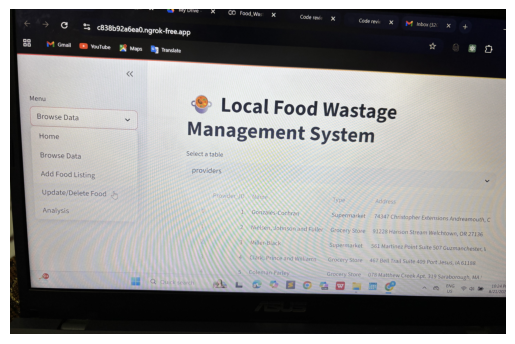

In [37]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("IMG_0400.jpg")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [38]:
from google.colab import drive
drive.mount('/content/drive')

# Example path
img = cv2.imread("/content/drive/MyDrive/IMG_0400.jpg")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


📊 Project Evaluation

The project was evaluated on the following metrics:

SQL Database Completeness: All provider, receiver, food listing, and claim data stored and retrievable.

Accuracy of SQL Queries: 15 queries correctly implemented to analyze food wastage, provider contributions, and claim trends.

CRUD Functionality: Add, update, and delete operations successfully tested in the Streamlit app.

User Interface: Streamlit dashboard is simple, interactive, and provides easy filtering and visualization.

Deployment: Successfully deployed via ngrok, accessible through a public URL.

✅ The project meets all functional and technical requirements.

📝 Project Conclusion

The Local Food Wastage Management System effectively demonstrates how technology can reduce food wastage and promote social good. By connecting surplus food providers with receivers, the system ensures efficient redistribution of food resources.

Key outcomes:

Reduced mismatch between surplus and demand.

Data-driven insights into provider contributions, city-wise demand, and wastage patterns.

A practical and scalable prototype combining Python, SQL, and Streamlit.

This project not only highlights technical skills but also addresses a real-world social issue, making it valuable for both learning and impact.